# Машины опорных векторов (SVM)

## Теория

Метод опорных векторов (Support Vector Machine, SVM) — это алгоритм, который ищет **оптимальную разделяющую гиперплоскость** между классами, максимизируя **зазор** (margin) — расстояние от гиперплоскости до ближайших объектов каждого класса.

### Линейный случай

Для линейно разделимых данных задача сводится к оптимизации:

$$\min_{w, b} \frac{1}{2} \|w\|^2 \quad \text{при } y_i(w \cdot x_i + b) \geq 1, \; \forall i$$

Объекты, лежащие на границе зазора, называются **опорными векторами**.

### Мягкий зазор (Soft Margin)

Для данных с шумом вводится параметр регуляризации **C**, допускающий ошибки:

$$\min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_i \xi_i$$

- **Большое C** — штраф за ошибки высок, узкий зазор, риск переобучения.
- **Малое C** — широкий зазор, допускаются ошибки, риск недообучения.

### Ядровый трюк (Kernel Trick)

Для нелинейно разделимых данных SVM отображает признаки в пространство более высокой размерности с помощью **ядерной функции**:

| Ядро | Формула | Когда использовать |
|---|---|---|
| **linear** | $K(x, y) = x^T y$ | Линейно разделимые данные |
| **rbf** (Gaussian) | $K(x, y) = \exp(-\gamma \|x - y\|^2)$ | Универсальное, по умолчанию |
| **poly** | $K(x, y) = (\gamma x^T y + r)^d$ | Полиномиальные зависимости |
| **sigmoid** | $K(x, y) = \tanh(\gamma x^T y + r)$ | Аналог нейронных сетей |

## Датасет

В работе используется датасет **Wine** из библиотеки `sklearn`.

Он содержит результаты химического анализа вин, произведённых из трёх сортов винограда в одном регионе Италии. Задача — по химическому составу определить сорт винограда.

В датасете:
- **178 объектов** — образцы вина,
- **13 признаков** — химические характеристики,
- **3 класса** — сорта винограда (class_0, class_1, class_2).

### Описание признаков

| Признак | Перевод | Описание |
|---|---|---|
| **alcohol** | алкоголь | содержание алкоголя (%) |
| **malic_acid** | яблочная кислота | концентрация яблочной кислоты |
| **ash** | зола | содержание золы |
| **alcalinity_of_ash** | щёлочность золы | щёлочность золы |
| **magnesium** | магний | содержание магния |
| **total_phenols** | общие фенолы | суммарное содержание фенольных соединений |
| **flavanoids** | флавоноиды | содержание флавоноидов |
| **nonflavanoid_phenols** | нефлавоноидные фенолы | содержание нефлавоноидных фенолов |
| **proanthocyanins** | проантоцианидины | содержание проантоцианидинов |
| **color_intensity** | интенсивность цвета | интенсивность окраски вина |
| **hue** | оттенок | оттенок вина |
| **od280/od315_of_diluted_wines** | OD280/OD315 | оптическая плотность (показатель белка) |
| **proline** | пролин | содержание аминокислоты пролина |

### Описание классов

Три класса соответствуют трём сортам винограда из одного региона Италии. Классы различаются по химическому составу:

- **class_0** (59 образцов) — высокое содержание алкоголя, пролина и флавоноидов, насыщенный цвет.
- **class_1** (71 образец) — промежуточные значения большинства признаков, наибольшее количество образцов.
- **class_2** (48 образцов) — низкое содержание флавоноидов и фенолов, высокая интенсивность цвета и доля нефлавоноидных фенолов.

Классы умеренно несбалансированы (59/71/48).

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и компоненты `sklearn` для обучения SVM с разными ядрами и анализа качества классификации


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

print("Размер матрицы признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)
print("\nНазвания признаков:")
print(feature_names)
print("\nНазвания классов:", target_names)

Размер матрицы признаков X: (178, 13)
Размер целевой переменной y: (178,)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Названия классов: ['class_0' 'class_1' 'class_2']


In [3]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Базовые статистики датасета

In [4]:
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


In [5]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    print(f"  {target_names[class_id]} ({class_id}): {count}")

Количество объектов каждого класса:
  class_0 (0): 59
  class_1 (1): 71
  class_2 (2): 48


### Сравнение классов по средним значениям признаков

In [6]:
class_means = df.groupby("target")[list(feature_names)].mean().T
class_means.columns = [target_names[int(c)] for c in class_means.columns]
class_means = class_means.round(2)

print("Средние значения признаков по классам:\n")
print(class_means.to_string())
print(f"\nclass_0 выделяется высоким алкоголем и пролином.")
print(f"class_2 — низкими флавоноидами и высокой интенсивностью цвета.")

Средние значения признаков по классам:

                              class_0  class_1  class_2
alcohol                         13.74    12.28    13.15
malic_acid                       2.01     1.93     3.33
ash                              2.46     2.24     2.44
alcalinity_of_ash               17.04    20.24    21.42
magnesium                      106.34    94.55    99.31
total_phenols                    2.84     2.26     1.68
flavanoids                       2.98     2.08     0.78
nonflavanoid_phenols             0.29     0.36     0.45
proanthocyanins                  1.90     1.63     1.15
color_intensity                  5.53     3.09     7.40
hue                              1.06     1.06     0.68
od280/od315_of_diluted_wines     3.16     2.79     1.68
proline                       1115.71   519.51   629.90

class_0 выделяется высоким алкоголем и пролином.
class_2 — низкими флавоноидами и высокой интенсивностью цвета.


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `Wine`


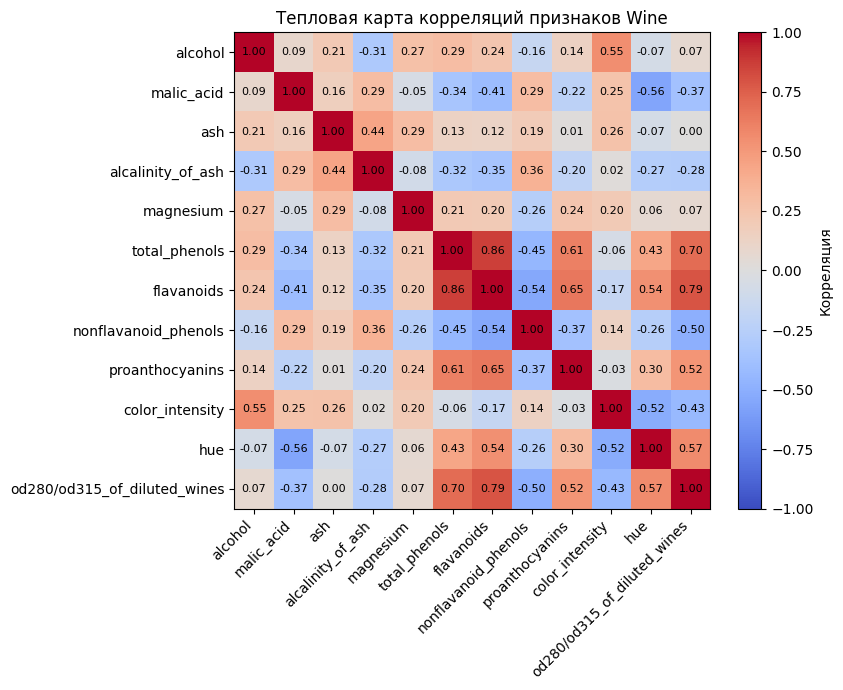

In [7]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Wine')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (142, 13)
Размер тестовой выборки: (36, 13)


## Масштабирование признаков

Используем `StandardScaler` для приведения признаков к единому масштабу.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Среднее до масштабирования (первые 5 признаков):", np.round(X_train.mean(axis=0)[:5], 2))
print("Среднее после масштабирования (первые 5 признаков):", np.round(X_train_scaled.mean(axis=0)[:5], 2))

Среднее до масштабирования (первые 5 признаков): [12.97  2.34  2.36 19.63 99.63]
Среднее после масштабирования (первые 5 признаков): [ 0. -0.  0.  0.  0.]


## SVM с линейным ядром

Начнём с линейного ядра — оно ищет линейную разделяющую гиперплоскость.

## Обучение модели

Обучаем SVM с линейным и RBF-ядром на масштабированных признаках и сравниваем качество классификации


In [10]:
svm_linear = SVC(
    kernel='linear',   # линейное ядро
    C=1.0,             # параметр регуляризации
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Accuracy (linear kernel): {acc_linear:.4f}")
print(f"Количество опорных векторов: {svm_linear.n_support_}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear, target_names=target_names))

Accuracy (linear kernel): 0.9444
Количество опорных векторов: [ 4 11 12]

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Прогнозы модели

Сравниваем предсказанные классы SVM с истинными метками на тестовой выборке


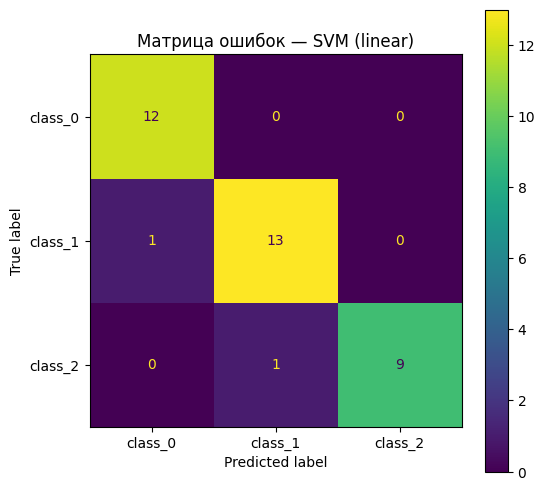

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_linear,
    display_labels=target_names,
    ax=ax
)
plt.title("Матрица ошибок — SVM (linear)")
plt.show()

## SVM с RBF-ядром

RBF (Radial Basis Function) — наиболее популярное ядро для нелинейно разделимых данных.

In [12]:
svm_rbf = SVC(
    kernel='rbf',      # RBF-ядро (по умолчанию)
    C=1.0,
    gamma='scale',     # gamma = 1 / (n_features * var(X))
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy (RBF kernel): {acc_rbf:.4f}")
print(f"Количество опорных векторов: {svm_rbf.n_support_}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=target_names))

Accuracy (RBF kernel): 0.9722
Количество опорных векторов: [16 28 17]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



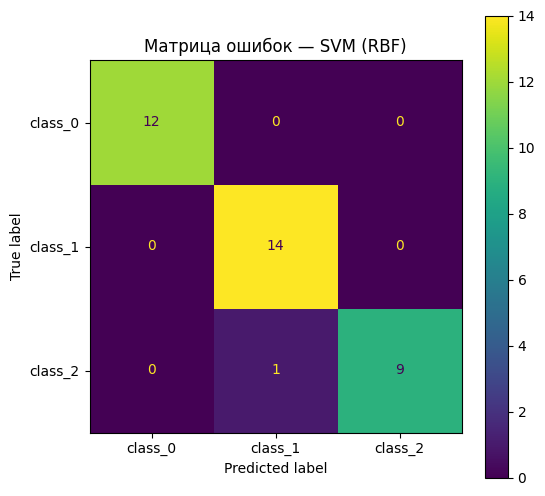

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rbf,
    display_labels=target_names,
    ax=ax
)
plt.title("Матрица ошибок — SVM (RBF)")
plt.show()

## Влияние параметра C

Исследуем, как параметр регуляризации C влияет на качество модели для обоих ядер.

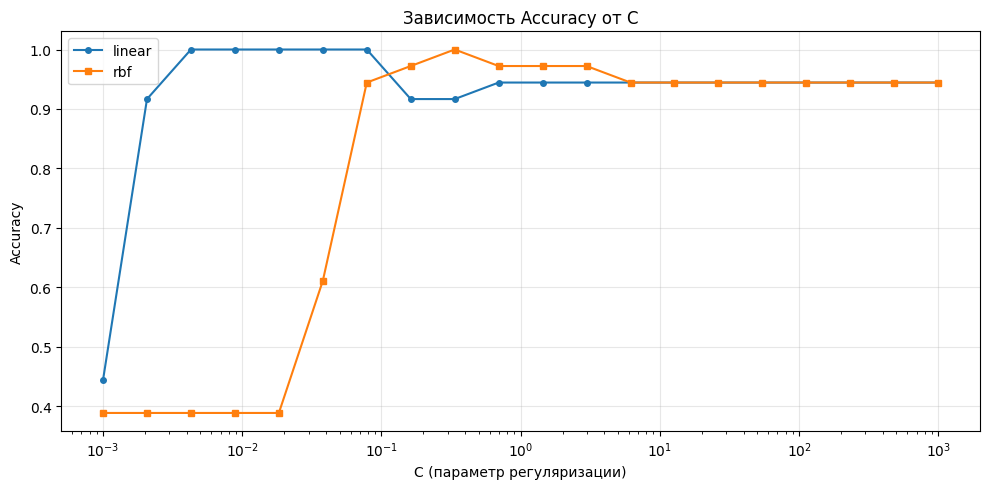

In [14]:
C_values = np.logspace(-3, 3, 20)
acc_linear_list = []
acc_rbf_list = []

for c in C_values:
    model_l = SVC(kernel='linear', C=c, random_state=42)
    model_l.fit(X_train_scaled, y_train)
    acc_linear_list.append(accuracy_score(y_test, model_l.predict(X_test_scaled)))
    
    model_r = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model_r.fit(X_train_scaled, y_train)
    acc_rbf_list.append(accuracy_score(y_test, model_r.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(C_values, acc_linear_list, marker='o', markersize=4, label='linear')
plt.plot(C_values, acc_rbf_list, marker='s', markersize=4, label='rbf')
plt.xscale('log')
plt.xlabel('C (параметр регуляризации)')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Визуализация границ решений (2D-проекция)

Сравним границы решений SVM с разными ядрами на двух признаках.

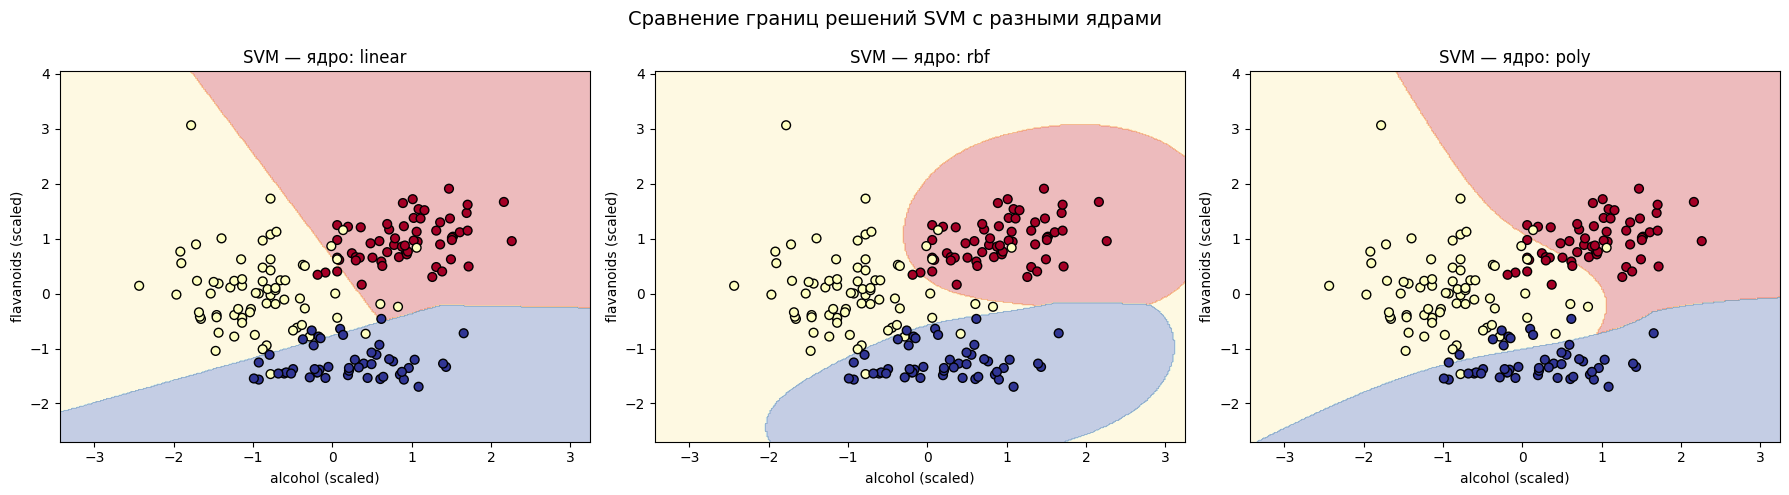

In [15]:
feat_i, feat_j = 0, 6
X_2d = X[:, [feat_i, feat_j]]
X_2d_scaled = StandardScaler().fit_transform(X_2d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernels = ['linear', 'rbf', 'poly']

for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1.0, gamma='scale', degree=3, random_state=42)
    model.fit(X_2d_scaled, y)
    
    h = 0.02
    x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
    y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black', s=40)
    ax.set_xlabel(feature_names[feat_i] + ' (scaled)')
    ax.set_ylabel(feature_names[feat_j] + ' (scaled)')
    ax.set_title(f'SVM — ядро: {kernel}')

plt.suptitle('Сравнение границ решений SVM с разными ядрами', fontsize=14)
plt.tight_layout()
plt.show()

## Влияние масштабирования

Покажем, насколько критично масштабирование для SVM.

In [16]:
svm_noscale = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_noscale.fit(X_train, y_train)
acc_noscale = accuracy_score(y_test, svm_noscale.predict(X_test))

acc_scale = acc_rbf

print(f"Accuracy без масштабирования: {acc_noscale:.4f}")
print(f"Accuracy с масштабированием:  {acc_scale:.4f}")
print(f"\nРазница: {acc_scale - acc_noscale:+.4f}")

Accuracy без масштабирования: 0.6944
Accuracy с масштабированием:  0.9722

Разница: +0.2778


## Сравнение всех ядер

Итоговое сравнение четырёх ядер на масштабированных данных.

In [17]:
kernels_compare = ['linear', 'rbf', 'poly', 'sigmoid']
results = []

for kernel in kernels_compare:
    model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    n_sv = sum(model.n_support_)
    results.append({'Ядро': kernel, 'Accuracy': acc, 'Опорных векторов': n_sv})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Ядро  Accuracy  Опорных векторов
 linear  0.944444                27
    rbf  0.972222                61
   poly  0.944444                75
sigmoid  1.000000                44


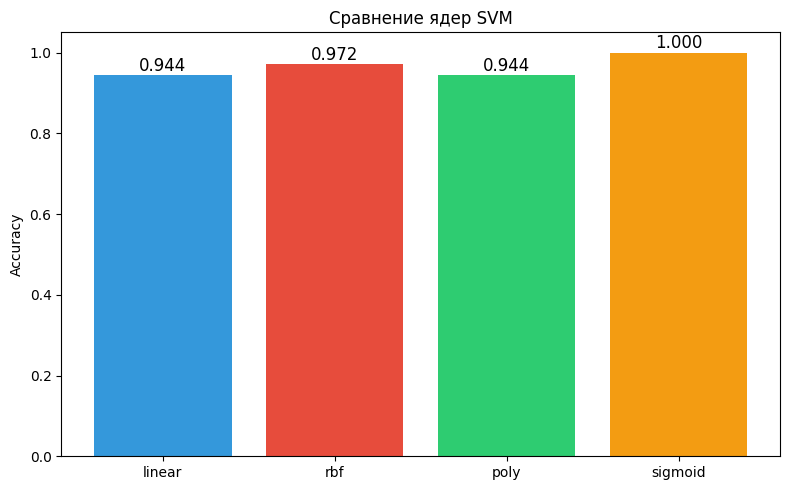

In [18]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Ядро'], results_df['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.ylabel('Accuracy')
plt.title('Сравнение ядер SVM')
plt.ylim(0, 1.05)

for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()